# **SEMINAR 3**

**On this occasion, we will focus on Wi-Fi fingerprinting, which is a low-complexity
technique to locate users within a given area. You will derive a K-Means model that
predicts the location of users based on their Received Signal Strength Indicator (RSSI).**

**PART** **1**

The dataset for this seminar (dataset Seminar3.zip) contains two files:
1. rssi data.csv: Wi-Fi RSSI measurements taken at K = 3 different APs (AP1, AP2,
and AP3), for P = 5 positions in which the STA was placed. In each row, there is the
RSSI perceived by each of the APs for a single measurement. The dataset includes
M = 300 measurements per location p ∈ P, thus it contains (P × M) × K values.
2. labels data.csv: The ground truth (i.e., the real position of the STA) for each measurement. (P × M) values are provided.
Once you load the data into your workspace, process it to provide the following plots:
*   2-D plots showing the RSSI perceived by each pair of APs (e.g., AP1 vs AP2).
*   A 3-D plot showing the RSSI perceived by each of the APs.
Apart from that, describe the statistics behind each of the considered points. For that, compute the average RSSI and the standard deviation obtained in each of the 5 studied locations. Plot the results.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import classification_report, accuracy_score
from sklearn import svm

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
path = '/content/drive/Shared drives//ML4N/seminar 3/'
rssi_data = pd.read_csv(path + 'rssi_data.csv',delimiter=',', header=None)
labels_data = pd.read_csv(path + 'labels_data.csv', delimiter=',', header=None)

2D plots showing the RSSI perceived by each pair of APs

In [ ]:
rssi_data.columns = ['AP1', 'AP2', 'AP3']
labels_data.columns = ["Position"]
data = pd.concat([rssi_data, labels_data], axis=1)
print(data.head())

# This table shows the RSSI measurements received from each access point and their corresponding location (label).

      AP1      AP2     AP3  Position
0 -21.949  -99.659 -42.257         5
1 -34.049  -95.964 -47.779         4
2 -18.861 -100.000 -34.175         5
3 -53.497  -77.368 -67.360         2
4 -54.986  -73.012 -69.780         2


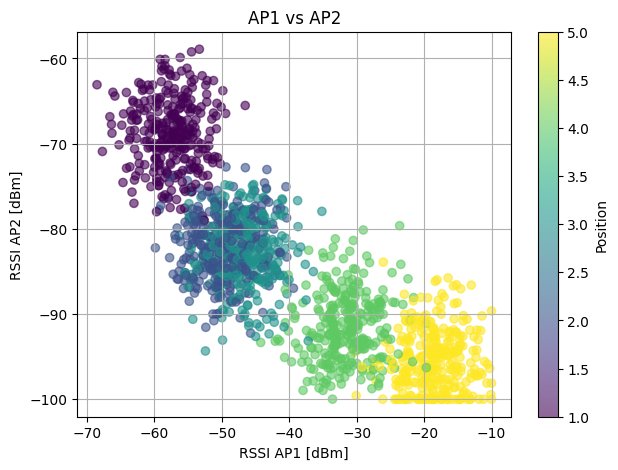

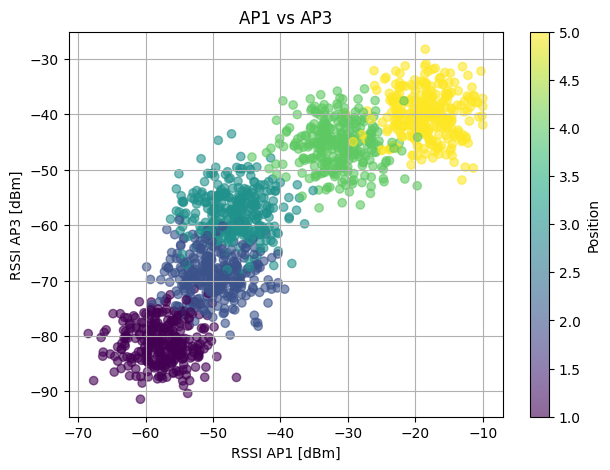

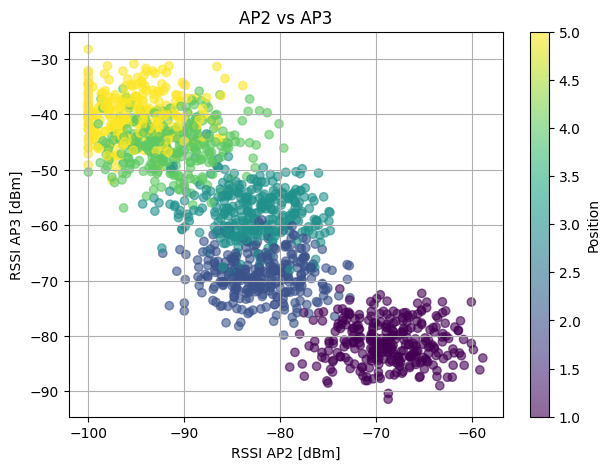

In [ ]:
pairs_AP = [("AP1", "AP2"), ("AP1", "AP3"), ("AP2", "AP3")]

for ap_x, ap_y in pairs_AP:
  plt.figure(figsize=(7, 5))

  plt.scatter(
      data[ap_x],
      data[ap_y],
      c=data["Position"],
      alpha=0.6
  )
  plt.xlabel(f"RSSI {ap_x} [dBm]")
  plt.ylabel(f"RSSI {ap_y} [dBm]")
  plt.title(f"{ap_x} vs {ap_y}")
  plt.colorbar(label="Position")
  plt.grid(True)
  plt.show()

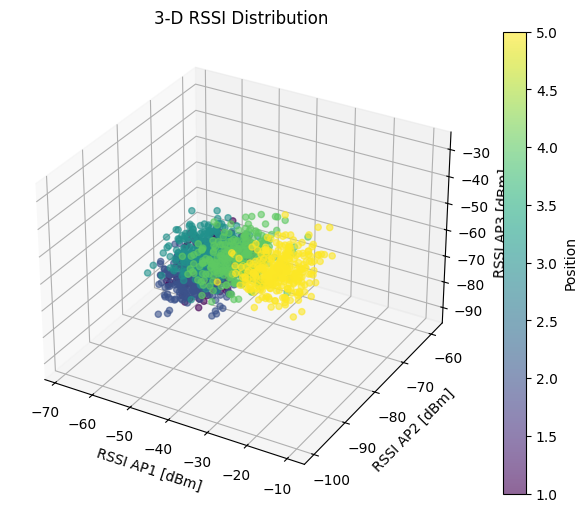

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    data["AP1"],
    data["AP2"],
    data["AP3"],
    c=data["Position"],
    alpha=0.6
)

ax.set_xlabel("RSSI AP1 [dBm]")
ax.set_ylabel("RSSI AP2 [dBm]")
ax.set_zlabel("RSSI AP3 [dBm]")
ax.set_title("3-D RSSI Distribution")

plt.colorbar(scatter, label="Position")
plt.show()

In [ ]:
mean_rssi = data.groupby("Position")[["AP1", "AP2", "AP3"]].mean()
std_rssi = data.groupby("Position")[["AP1", "AP2", "AP3"]].std()

print(mean_rssi)
print(std_rssi)

                AP1        AP2        AP3
Position                                 
1        -57.547793 -68.772187 -81.156930
2        -49.811667 -81.979633 -68.978473
3        -46.740827 -82.877667 -57.633320
4        -31.584760 -91.492630 -45.475647
5        -18.477953 -95.344790 -40.081403
               AP1       AP2       AP3
Position                              
1         3.676167  4.041594  3.748209
2         3.892066  3.760133  3.869161
3         3.951756  3.981708  4.141495
4         4.058027  3.944587  4.102736
5         3.860880  3.531129  4.128701


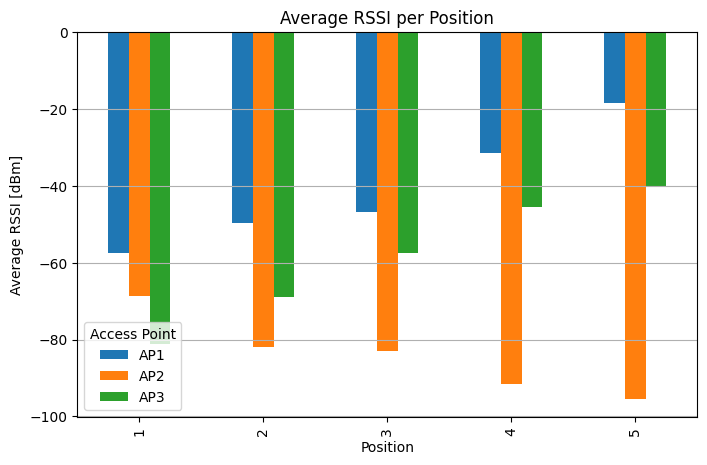

In [ ]:
mean_rssi.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Position")
plt.ylabel("Average RSSI [dBm]")
plt.title("Average RSSI per Position")
plt.grid(axis="y")
plt.legend(title="Access Point")
plt.show()

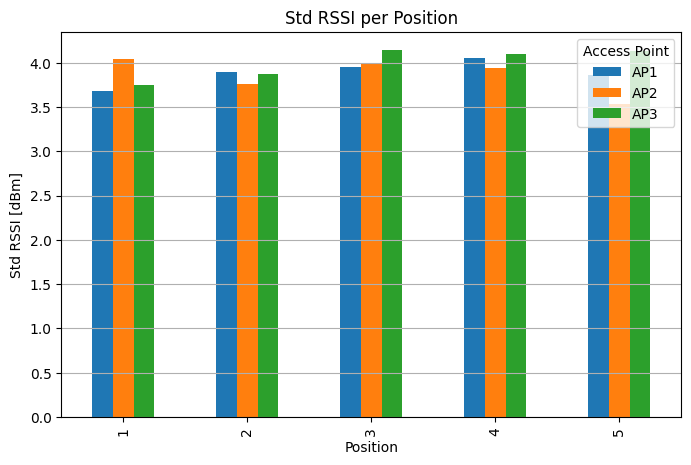

In [ ]:
std_rssi.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Position")
plt.ylabel("Std RSSI [dBm]")
plt.title("Std RSSI per Position")
plt.grid(axis="y")
plt.legend(title="Access Point")
plt.show()

Based on the three generated graphs, we can say that:

- Position 1 (Purple): Located at approximately -57.55 dBm from AP1, -68.77 dBm from AP2, and -81.16 dBm from AP3.

- Position 2 (Dark blue): Located at approximately -49.81 dBm from AP1, -81.98 dBm from AP2, and -68.98 dBm from AP3.

- Position 3 (Light blue): Located at approximately -46.74 dBm from AP1, -82.88 dBm from AP2, and -57.63 dBm from AP3.

- Position 4 (Green): Located at approximately -31.58 dBm from AP1, -91.49 dBm from AP2, and -45.48 dBm from AP3.

- Position 5 (Yellow): Located at approximately -18.48 dBm from AP1, -95.34 dBm from AP2, and -40.08 dBm from AP3.

We can observe that:

For AP1:

- Closest position: Position 5

- Furthest position: Position 1

For AP2:

- Closest position: Position 1

- Furthest position: Position 5

For AP3:

- Closest position: Position 5

- Furthest position: Position 1

We observe that Position 5 is the closest to AP1 and AP3, while Position 1 is the furthest from them. Likewise, Position 1 is the closest to AP2, while Position 5 is the most distant. Based on these data, we can conclude that AP1 and AP3 are located closer to each other, while AP2 is positioned further away from both.

The graphs show that the clusters for each position are relatively well-defined and easy to separate. We have 5 clusters, and each one can be assigned to a specific position.

**PART** **2**

Implement a simple K-Means algorithm (by hand) that performs the following operations:

• Initializes the centroids randomly in 3D space.

• Iteratively updates the centroids by following these two steps:

– Assign each point in the dataset to a centroid by calculating the Euclidean distance between the point and each centroid. The selected centroid should be the
one that is closest in distance to the point.

– Update the centroid of each cluster as the mean position of the points in that
cluster.1

• Check if the algorithm has converged. For that, establish two conditions:

– The assignment of clusters to each point in the dataset does not vary from one
iteration to another.

– A maximum number of iterations (T = 100) is reached.
Once your K-Means implementation is ready, use it in the Wi-Fi fingerprinting dataset to determine the location of each point. Compare the results with the ground truth and plot the results.

In [ ]:
def k_means(data, K, T): #We receive the data, the number of clusters, and the maximum number of iterations

  n_points, n_features = data.shape

  #We choose $k$ random points from the dataset and use them as initial centroids
  random_points = np.random.choice(n_points, K, replace=False)
  centroids = data[random_points]

  #Initialize this variable to check for changes later
  #Since there is no previous assignment before the first iteration, we initialize it to 0
  previous_assigments = np.zeros(n_points)

  for i in range(T):
    dist = np.zeros((n_points, K)) #Distance matrix initialized to 0 at the beginning

    #For each centroid k
    for k in range(K):
      #Compute the Euclidean distance between all data points and centroid k
      dist[:,k] = np.linalg.norm(data - centroids[k], axis=1)

    assigments = np.argmin(dist, axis=1) #For each point, we find the column with the shortest distance

    #Check if it has converged (if the assignments do not change)
    if np.array_equal(assigments, previous_assigments):
      print("Convergence achieved")
      break

    previous_assigments = assigments.copy() #Save the new assignments

    #Actualize centroides
    for k in range(K):
      points_cluster = data[assigments == k] #Get all points belonging to cluster k
      if len(points_cluster) > 0:
        centroids[k] = points_cluster.mean(axis=0) #Calculate the average coordinates of the points in this cluster to define the new centroid

  return assigments, centroids

In [ ]:
cluster_assigments, centroids = k_means(rssi_data.values, K=5, T=100)
print(centroids)

# Aquests són els resultats (els dBm de cada AP per a cada posició) del nostre algorisme k-means
#      AP1 AP2 AP3
#pos 1
#pos 2
#pos 3
#pos 4
#pos 5

Convergence achieved
[[-46.05199042 -83.44111182 -56.72059105]
 [-58.50189595 -66.40647399 -82.36856069]
 [-56.15911111 -72.17722222 -79.16651852]
 [-24.5507301  -93.56073529 -42.51134602]
 [-49.64118605 -82.10184053 -68.88833223]]


In [ ]:
#To find the real position
def map_clusters_to_positions(cluster_assignments, y_true):
    cluster_to_position = {}

    for cluster in np.unique(cluster_assignments):
        true_positions = y_true[cluster_assignments == cluster]

        most_common_position = pd.Series(true_positions).mode()[0]

        cluster_to_position[cluster] = most_common_position

    return cluster_to_position

In [ ]:
y_true = labels_data.values.ravel()
cluster_to_position = map_clusters_to_positions(cluster_assigments, y_true)

print("Equivalencia cluster -> posición real:")
print(cluster_to_position)

y_pred = np.array([
    cluster_to_position[cluster]
    for cluster in cluster_assigments
])


Equivalencia cluster -> posición real:
{np.int64(0): np.int64(3), np.int64(1): np.int64(1), np.int64(2): np.int64(1), np.int64(3): np.int64(5), np.int64(4): np.int64(2)}


In [ ]:
accuracy = np.mean(y_pred == y_true)
print("Accuracy:", accuracy)

Accuracy: 0.7713333333333333


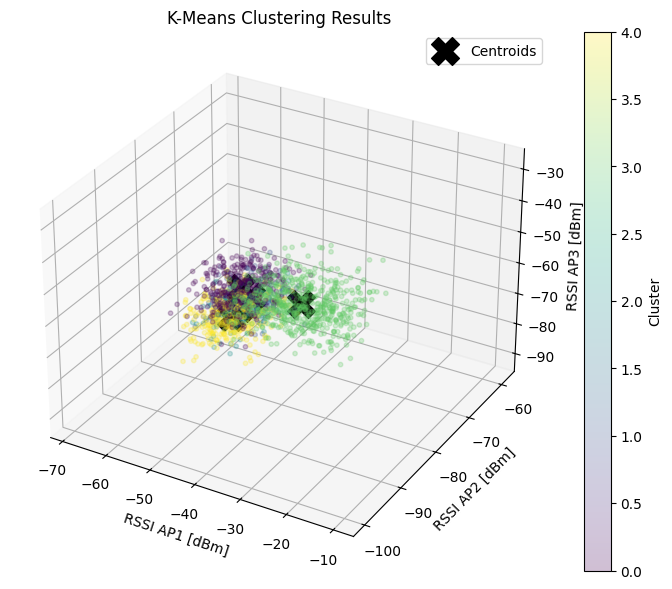

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")

# Points of the dataset
scatter = ax.scatter(
    data["AP1"],
    data["AP2"],
    data["AP3"],
    c=cluster_assigments,
    alpha=0.25,
    s=10
)

# Centroides
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    c="black",
    marker="X",
    s=400,
    label="Centroids",
    depthshade=False
)

ax.set_xlabel("RSSI AP1 [dBm]")
ax.set_ylabel("RSSI AP2 [dBm]")
ax.set_zlabel("RSSI AP3 [dBm]")
ax.set_title("K-Means Clustering Results")

plt.colorbar(scatter, label="Cluster")
ax.legend()
plt.show()

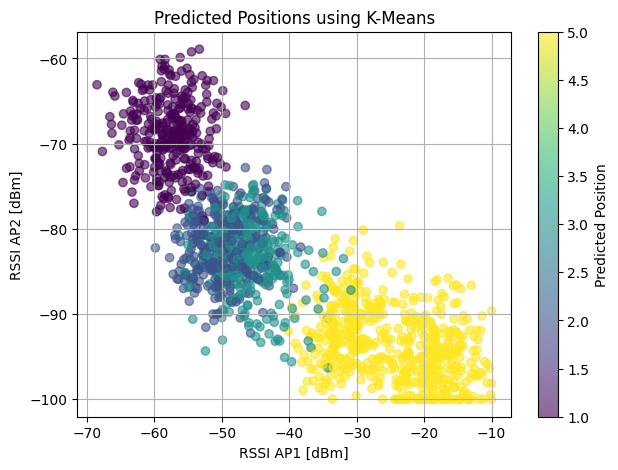

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    data["AP1"],
    data["AP2"],
    c=y_pred,
    alpha=0.6
)

plt.xlabel("RSSI AP1 [dBm]")
plt.ylabel("RSSI AP2 [dBm]")
plt.title("Predicted Positions using K-Means")
plt.colorbar(label="Predicted Position")
plt.grid(True)
plt.show()

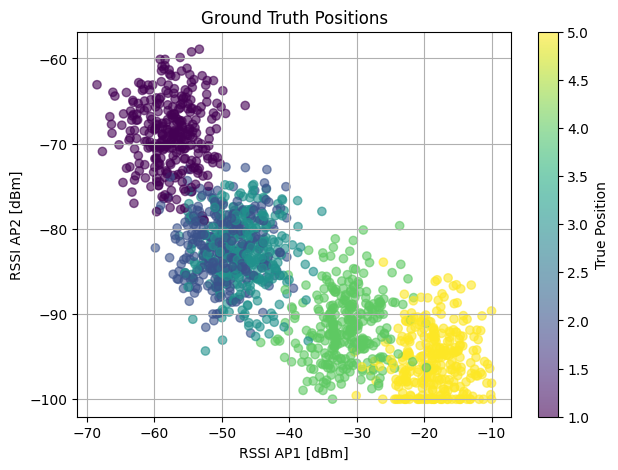

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    data["AP1"],
    data["AP2"],
    c=y_true,
    alpha=0.6
)

plt.xlabel("RSSI AP1 [dBm]")
plt.ylabel("RSSI AP2 [dBm]")
plt.title("Ground Truth Positions")
plt.colorbar(label="True Position")
plt.grid(True)
plt.show()

We observe the labels that the algorithm has assigned to the different clusters:

- Cluster 0 -> pos 3
- Cluster 1 -> pos 1
- Cluster 2 -> pos 1
- Cluster 3 -> pos 5
- Cluster 4 -> pos 2

If we analyze the graphs and compare the prediction plot with the ground truth plot, we see that what happens is that the cluster assigned to Position 5 is actually two clusters merged together; it consists of the cluster assigned to Position 5 in the ground truth plus the cluster assigned to Position 4. Regarding the other data, the algorithm groups them well, correctly identifying those belonging to positions 1, 2, and 3. However, the fifth cluster is created within Position 1, which should actually be just one cluster but instead results in two.

We see that the algorithm has not assigned any cluster to Position 4. If we analyze and compare the prediction graph with the ground truth, we see that the samples from positions 4 and 5 have been grouped into a single large cluster, which has been assigned to Position 5. On the other hand, the algorithm has correctly grouped the data for positions 1, 2, and 3. However, since the algorithm knows there must be 5 clusters (K=5) and has merged positions 4 and 5 into one, it has used the leftover cluster to split Position 1 into two distinct groups (clusters 1 and 2), when in reality there should only be one cluster for Position 1.

Therefore, these results explain the obtained accuracy, which is approximately 77%. In conclusion, K-means does its job quite well, offering a correct approximation of reality, although it is not perfect due to signal similarities in certain areas.